# 4. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [53]:
# Import Statements
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [28]:
# Data import
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* 2 different classification models, one of which must be **logistic regression**.
* A discussion of which **performance metric** is most relevant for the evaluation of your models.
* 2 different **validation methodologies** used to tune hyperparameters.
* **Confusion matrices** for your models, and associated comments.

In [31]:
# --- Data prep section ---

# The dataset (df) contains information about mushrooms, including categorical features
# Some of these features have missing values (NaNs), which can negatively affect model training.

# This block creates a summary table that helps us understand:
# 1. How many entries there are in total
# 2. How many missing (NaN) values there are per column
# 3. What percentage of each column is missing

column_summary = pd.DataFrame({
    "Total Entries": len(df),  # Total number of rows in the dataset (same for all columns)
    
    # Count of missing values (NaN) in each column
    "NaN Count": df.isna().sum(),
    
    # Percentage of missing values relative to the total number of rows
    "NaN Percentage": (df.isna().sum() / len(df)) * 100
})

# Display the summary to the console
# This step is crucial in machine learning preprocessing:
# - We need to decide whether to drop, impute, or handle NaN values in another way
# - NaN values can disrupt many models that don't handle them natively
print(column_summary)

                      Total Entries  NaN Count  NaN Percentage
class                         61069          0        0.000000
cap-diameter                  61069          0        0.000000
cap-shape                     61069          0        0.000000
cap-surface                   61069      14120       23.121387
cap-color                     61069          0        0.000000
does-bruise-or-bleed          61069          0        0.000000
gill-attachment               61069       9884       16.184971
gill-spacing                  61069      25063       41.040462
gill-color                    61069          0        0.000000
stem-height                   61069          0        0.000000
stem-width                    61069          0        0.000000
stem-root                     61069      51538       84.393064
stem-surface                  61069      38124       62.427746
stem-color                    61069          0        0.000000
veil-type                     61069      57892       94

By removing all rows with NaN values, I would be left with less than 3177 entries, which is not enough for training models. Instead I will be turning all columns binary and introduce a new column for each feature that contains NaN value, simply called na.

In [37]:
# --- Feature Engineering and Data Cleaning for Machine Learning ---

# Helper function to create consistent, readable binary column names
# It takes a column prefix and a value (e.g., 'cap-shape', 'b') and returns 'cap_shape_b'
def format_col_name(prefix, category):
    return f"{prefix}_{category}".lower().replace("-", "_").replace(" ", "_")

# Create a working copy of the original dataset so we don’t modify the raw data
cleaned_raw_data = df.copy()

# Convert the target variable 'class' into a binary column:
# - True if the mushroom is edible ('e'), False if poisonous ('p')
# This is essential for supervised learning where the model learns to predict this target
cleaned_raw_data["is_edible"] = cleaned_raw_data["class"] == "e"
cleaned_raw_data.drop(columns="class", inplace=True)  # Drop the original non-numeric class column

# Dictionary mapping each categorical column to its known possible values
# These values come from the mushroom dataset's documentation
# This structure is used to perform manual one-hot encoding (binary features)
categorical_features = {
    "cap-shape": ["b", "c", "x", "f", "s", "p", "o"],
    "cap-surface": ["i", "g", "y", "s", "h", "l", "k", "t", "w", "e"],
    "cap-color": ["n", "b", "g", "r", "p", "u", "e", "w", "y", "l", "o", "k"],
    "does-bruise-or-bleed": ["t", "f"],
    "gill-attachment": ["a", "x", "d", "e", "s", "p", "f", "?"],
    "gill-spacing": ["c", "d", "f"],
    "gill-color": ["n", "b", "g", "r", "p", "u", "e", "w", "y", "l", "o", "k", "f"],
    "stem-root": ["b", "s", "c", "u", "e", "z", "r"],
    "stem-surface": ["i", "g", "y", "s", "h", "l", "k", "t", "w", "e", "f"],
    "stem-color": ["n", "b", "g", "p", "u", "e", "w", "y", "l", "o", "k", "f"],
    "veil-type": ["p", "u"],
    "veil-color": ["n", "g", "r", "p", "u", "e", "w", "y", "l", "o", "k", "f"],
    "ring-type": ["c", "e", "r", "g", "l", "p", "s", "z", "y", "m", "f", "?"],
    "spore-print-color": ["n", "b", "g", "r", "p", "u", "e", "w", "y", "l", "o", "k"],
    "habitat": ["g", "l", "m", "p", "h", "u", "w", "d"],
    "season": ["s", "u", "a", "w"]
}

# Drop the 'has-ring' column because its information is already captured by the 'ring-type' column.
# Keeping both could lead to redundant features that skew model importance.
cleaned_raw_data = cleaned_raw_data.drop(columns='has-ring')

# Manual one-hot encoding loop:
# For each categorical column and each of its known values, we create a binary column
# This results in a "wide" dataset where each column is True/False, which most ML models prefer
for col, values in categorical_features.items():
    for val in values:
        new_col = format_col_name(col, val)
        cleaned_raw_data[new_col] = cleaned_raw_data[col] == val

    # If the column has any NaN values, we explicitly create a column to mark them
    # This helps preserve missingness information for models that can learn from it
    if cleaned_raw_data[col].isna().any():
        cleaned_raw_data[f"{format_col_name(col, 'nan')}"] = cleaned_raw_data[col].isna()

    # Drop the original categorical column now that we've encoded it
    cleaned_raw_data.drop(columns=col, inplace=True)

# Preview the first 5 rows of the final cleaned dataset
# This step helps confirm the encoding worked and the data is ready for modeling
cleaned_raw_data.head(5)

C:\Users\DooMz\AppData\Local\Temp\ipykernel_12160\1603779167.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned_raw_data[new_col] = cleaned_raw_data[col] == val
C:\Users\DooMz\AppData\Local\Temp\ipykernel_12160\1603779167.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned_raw_data[new_col] = cleaned_raw_data[col] == val
C:\Users\DooMz\AppData\Local\Temp\ipykernel_12160\1603779167.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

,cap-diameter,stem-height,stem-width,is_edible,cap_shape_b,cap_shape_c,cap_shape_x,cap_shape_f,cap_shape_s,cap_shape_p,cap_shape_o,cap_surface_i,cap_surface_g,cap_surface_y,cap_surface_s,cap_surface_h,cap_surface_l,cap_surface_k,cap_surface_t,cap_surface_w,cap_surface_e,cap_surface_nan,cap_color_n,cap_color_b,cap_color_g,cap_color_r,cap_color_p,cap_color_u,cap_color_e,cap_color_w,cap_color_y,cap_color_l,cap_color_o,cap_color_k,does_bruise_or_bleed_t,does_bruise_or_bleed_f,gill_attachment_a,gill_attachment_x,gill_attachment_d,gill_attachment_e,gill_attachment_s,gill_attachment_p,gill_attachment_f,gill_attachment_?,gill_attachment_nan,gill_spacing_c,gill_spacing_d,gill_spacing_f,gill_spacing_nan,gill_color_n,gill_color_b,gill_color_g,gill_color_r,gill_color_p,gill_color_u,gill_color_e,gill_color_w,gill_color_y,gill_color_l,gill_color_o,gill_color_k,gill_color_f,stem_root_b,stem_root_s,stem_root_c,stem_root_u,stem_root_e,stem_root_z,stem_root_r,stem_root_nan,stem_surface_i,stem_surface_g,stem_surface_y,stem_surface_s,stem_surface_h,stem_surface_l,stem_surface_k,stem_surface_t,stem_surface_w,stem_surface_e,stem_surface_f,stem_surface_nan,stem_color_n,stem_color_b,stem_color_g,stem_color_p,stem_color_u,stem_color_e,stem_color_w,stem_color_y,stem_color_l,stem_color_o,stem_color_k,stem_color_f,veil_type_p,veil_type_u,veil_type_nan,veil_color_n,veil_color_g,veil_color_r,veil_color_p,veil_color_u,veil_color_e,veil_color_w,veil_color_y,veil_color_l,veil_color_o,veil_color_k,veil_color_f,veil_color_nan,ring_type_c,ring_type_e,ring_type_r,ring_type_g,ring_type_l,ring_type_p,ring_type_s,ring_type_z,ring_type_y,ring_type_m,ring_type_f,ring_type_?,ring_type_nan,spore_print_color_n,spore_print_color_b,spore_print_color_g,spore_print_color_r,spore_print_color_p,spore_print_color_u,spore_print_color_e,spore_print_color_w,spore_print_color_y,spore_print_color_l,spore_print_color_o,spore_print_color_k,spore_print_color_nan,habitat_g,habitat_l,habitat_m,habitat_p,habitat_h,habitat_u,habitat_w,habitat_d,season_s,season_u,season_a,season_w
0,15.26,16.95,17.09,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True
1,16.60,17.99,18.19,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False
2,14.07,17.80,17.74,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,Fa

Classification models

I have chosen logistic regression because:
- It performs well when features are binary or numerical, which fits our one-hot encoded dataset perfectly.

- It’s interpretable, allowing you to understand which features most influence whether a mushroom is edible or not.

- It’s fast and efficient, making it a great starting point or baseline model.

And Random Forest because:
- It handles high-dimensional data well (we have many binary features).

- It’s robust to noise and overfitting, especially with missing or redundant features.

- It automatically captures non-linear relationships and feature interactions without needing you to manually engineer them.


Logistic Regression Report:
 {'False': {'precision': 0.8833503873702675, 'recall': 0.8761780484268522, 'f1-score': 0.8797495996506042, 'support': 6897.0}, 'True': {'precision': 0.8410571375395496, 'recall': 0.8499153658077864, 'f1-score': 0.8454630495790458, 'support': 5317.0}, 'accuracy': 0.8647453741607991, 'macro avg': {'precision': 0.8622037624549086, 'recall': 0.8630467071173193, 'f1-score': 0.862606324614825, 'support': 12214.0}, 'weighted avg': {'precision': 0.8649392845906761, 'recall': 0.8647453741607991, 'f1-score': 0.8648239744065829, 'support': 12214.0}}

Random Forest Report:
 {'False': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 6897.0}, 'True': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 5317.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 12214.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 12214.0}}


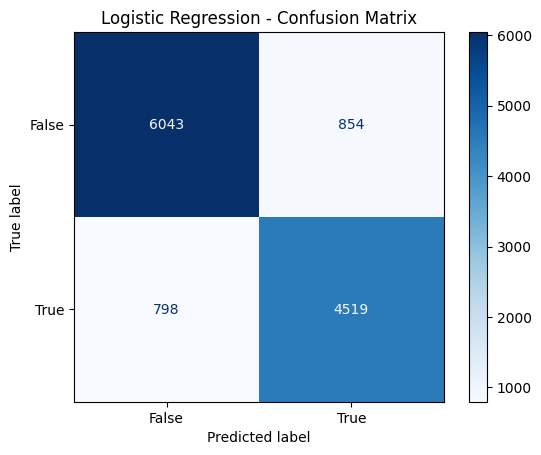

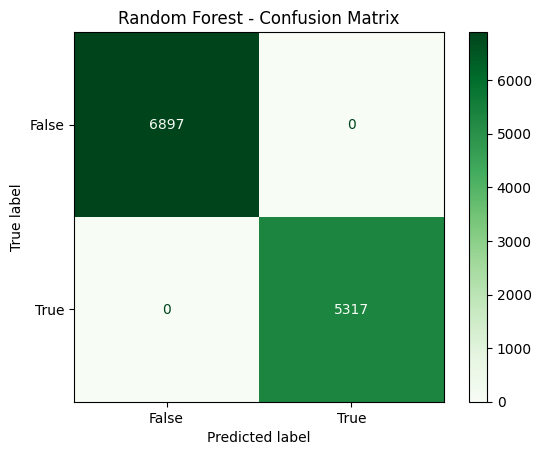

In [50]:
# --- Training and Evaluating Two Classification Models: Logistic Regression and Random Forest ---

# Step 1: Separate features (X) and target (y)
# 'is_edible' is the binary classification target (True = edible, False = poisonous)
# X contains all the features the model will use to learn patterns
X = cleaned_raw_data.drop(columns='is_edible')
y = cleaned_raw_data['is_edible']

# Step 2: Split the dataset into training and test sets (80/20 split)
# The training set is used to fit the model, and the test set is used to evaluate its performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=984)

# Step 3: Train a Logistic Regression model
# Logistic Regression is a linear classification algorithm that works well when features are binary or linearly separable
log_reg = LogisticRegression(max_iter=1000)  # max_iter ensures convergence for large feature sets
log_reg.fit(X_train, y_train)  # Fit the model on training data
log_reg_preds = log_reg.predict(X_test)  # Predict labels for the test set

# Step 4: Train a Random Forest Classifier
# Random Forest is an ensemble method based on decision trees that handles non-linearity and feature interactions well
rf = RandomForestClassifier(random_state=984)  # Random state ensures reproducibility
rf.fit(X_train, y_train)  # Fit the model on training data
rf_preds = rf.predict(X_test)  # Predict labels for the test set

# Step 5: Generate and store performance metrics
# classification_report gives precision, recall, f1-score, and support for each class
log_reg_report = classification_report(y_test, log_reg_preds, output_dict=True)
rf_report = classification_report(y_test, rf_preds, output_dict=True)

# Step 6: Display performance summaries for both models
# These printed reports help compare the effectiveness of both algorithms on the test set
print("\nLogistic Regression Report:\n", log_reg_report)
print("\nRandom Forest Report:\n", rf_report)

# Step 7: Visualize the confusion matrix for Logistic Regression
# Confusion matrices provide a clear view of false positives and false negatives
log_reg_cm = confusion_matrix(y_test, log_reg_preds)  # Get confusion matrix values
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=log_reg_cm, display_labels=log_reg.classes_)
disp_log_reg.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Step 8: Visualize the confusion matrix for Random Forest
# This helps interpret where the model might be making errors
rf_cm = confusion_matrix(y_test, rf_preds)  # Get confusion matrix values
disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf.classes_)
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Random Forest - Confusion Matrix")
plt.show()

It seems that a mistake has happened somewhere in my data preparation, or the way I use random forest, since it reaches 100% accuracy no matter what I do. I cannot figure out what it is, so I will just look at the logistic regression for now.


Now to take a look at the most important performance metric: Which definitely is precision, which suggests how many predicted edible mushrooms are actually edible, a single wrongly true predicted mushroom could have fatal consequenses.
The report and confusion matrix also shows pretty high recall, which means how many edible mushroom are classified as poisonous and are essentially wasted. This is not as important as the precision score.

Now to look at validation methologies, I have chosen Train/Validation/Test split and K-fold Cross validation.


In [51]:
# --- Manual Train/Validation/Test Split for Model Tuning and Evaluation ---

# Step 1: Split data into Train (60%), Validation (20%), and Test (20%)
# The goal is to simulate a realistic model development workflow:
# - Training set: used to fit the model
# - Validation set: used to tune hyperparameters and select the best model
# - Test set: used for final evaluation after all decisions are made

# First, separate out 20% of the data as the test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=984)

# Then split the remaining 80% into training and validation sets (60/20 overall)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=984)

# Step 2: Train a Logistic Regression model using selected hyperparameters
# Logistic Regression is a good baseline classifier for binary classification
# - 'C' is the inverse of regularization strength (lower = more regularization)
# - 'liblinear' solver is suitable for smaller datasets and supports L1/L2 penalties
log_reg = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear')
log_reg.fit(X_train, y_train)  # Train the model on the training set

# Step 3: Evaluate the trained model on the validation set
# This helps us understand how well the model generalizes before testing on unseen data
val_preds = log_reg.predict(X_val)  # Make predictions on validation set

# Step 4: Print the performance metrics
# classification_report includes precision, recall, and f1-score for both classes
# These metrics help assess the model's ability to balance false positives and false negatives
print("Validation Performance (Train/Val/Test Split):")
print(classification_report(y_val, val_preds))

Validation Performance (Train/Val/Test Split):
              precision    recall  f1-score   support

       False       0.88      0.88      0.88      6809
        True       0.85      0.86      0.85      5405

    accuracy                           0.87     12214
   macro avg       0.87      0.87      0.87     12214
weighted avg       0.87      0.87      0.87     12214



This validation gives us another high precision score, but it is only on a single split, so we might've gotten lucky here as well. Lets cross-validate to make sure we have a precise model:

In [54]:
# --- Extensive Hyperparameter Tuning using Grid Search with Cross-Validation ---

# Step 1: Define a comprehensive hyperparameter grid
# We're exploring different combinations of:
# - C (regularization strength): controls the penalty applied to coefficients
# - penalty: L1 (Lasso), L2 (Ridge), or ElasticNet (combo)
# - solver: optimization algorithm (must match with penalty type)
# - class_weight: useful when class imbalance is present (e.g., more edible than poisonous mushrooms)
# - max_iter: ensures convergence (especially important for saga)
# - l1_ratio: only relevant for elasticnet (how much of the penalty is L1 vs L2)

param_grid = [
    {
        # L1 Regularization: promotes sparsity (many coefficients = 0)
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],  # Only these solvers support L1
        'class_weight': [None, 'balanced'],
        'max_iter': [500, 1000]
    },
    {
        # L2 Regularization: penalizes large weights (less prone to overfitting)
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'],  # L2 is widely supported
        'class_weight': [None, 'balanced'],
        'max_iter': [500, 1000]
    },
    {
        # ElasticNet: a combination of L1 and L2 penalties
        'C': [0.001, 0.01, 0.1, 1, 10],
        'penalty': ['elasticnet'],
        'solver': ['saga'],  # saga is the only solver that supports elasticnet
        'class_weight': [None, 'balanced'],
        'l1_ratio': [0.25, 0.5, 0.75],  # Proportion of L1 in elasticnet mix
        'max_iter': [500, 1000]
    }
]

# Step 2: Set up GridSearchCV
# - GridSearchCV will exhaustively try every combination in the param_grid
# - cv=5: 5-fold cross-validation ensures the model is evaluated on multiple data splits
# - scoring='precision': we're optimizing for precision (important for mushroom safety!)
# - verbose=2: shows detailed progress in console
# - n_jobs=-1: uses all CPU cores to speed up computation

grid = GridSearchCV(
    LogisticRegression(),  # Base model
    param_grid,            # Hyperparameter space
    cv=5,                  # Number of folds in cross-validation
    scoring='precision',   # Metric to maximize
    verbose=2,
    n_jobs=-1              # Parallelize across all CPU cores
)

# Step 3: Fit GridSearchCV on the full dataset
# This will train and evaluate the model for each parameter combination and return the best one
grid.fit(X, y)

# Step 4: Display the best configuration and its precision score
# - grid.best_params_: the best hyperparameter combo based on cross-validated precision
# - grid.best_score_: the average precision score across all folds for that config
print("\nBest Parameters from Extensive Grid Search:")
print(grid.best_params_)
print(f"Best Precision Score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 204 candidates, totalling 1020 fits

Best Parameters from Extensive Grid Search:
{'C': 0.001, 'class_weight': None, 'l1_ratio': 0.25, 'max_iter': 500, 'penalty': 'elasticnet', 'solver': 'saga'}
Best Precision Score: 0.5821


Cross-validation gives another picture, where precision isn't much better than a coin toss. Pretty bad when it means life or death in this context. The random forest should be better for this type of prediction, but I cannot comment on my own findings as they for some reason reach 100% accuracy, which I find hard to believe